In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet(
    "../data/processed/trips_clean.parquet"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (3227370, 33)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_date,pickup_month,is_weekend,time_period,fare_per_mile,fare_per_minute,duration_per_mile,tip_rate,ratecode_label,payment_type_label
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,2025-01-01,1,False,Night,6.250000,1.197605,5.218750,0.300000,Standard rate,Credit card
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,2025-01-01,1,False,Night,10.200000,2.000000,5.100000,0.396078,Standard rate,Credit card
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,2025-01-01,1,False,Night,8.500000,2.615385,3.250000,0.392157,Standard rate,Credit card
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,2025-01-01,1,False,Night,13.846154,1.293413,10.705128,0.000000,Standard rate,Cash
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,2025-01-01,1,False,Night,8.787879,1.641509,5.353535,0.000000,Standard rate,Cash


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3227370 entries, 0 to 3227369
Data columns (total 33 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3227370.0,1.779177,1.0,2.0,2.0,2.0,6.0,0.417311
tpep_pickup_datetime,3227370,2025-01-17 09:46:56.698464,2025-01-01 00:00:00,2025-01-10 02:03:56,2025-01-17 14:10:27,2025-01-24 19:23:16,2025-01-31 23:59:59,NaN
tpep_dropoff_datetime,3227370,2025-01-17 10:01:37.930256,2025-01-01 00:02:49,2025-01-10 02:15:39.500000,2025-01-17 14:27:34,2025-01-24 19:37:37,2025-02-01 01:10:26,NaN
passenger_count,3227370.0,1.267276,1.0,1.0,1.0,1.0,6.0,0.700352
trip_distance,3227370.0,3.172242,0.01,1.01,1.7,3.15,97.58,4.15051
RatecodeID,3227370.0,14.784852,1.0,1.0,1.0,1.0,99.0,33.992987
PULocationID,3227370.0,165.639666,1.0,132.0,162.0,234.0,265.0,64.26379
DOLocationID,3227370.0,164.572927,1.0,114.0,162.0,234.0,265.0,69.312343
payment_type,3227370.0,1.024931,0.0,1.0,1.0,1.0,4.0,0.594577
fare_amount,3227370.0,18.232079,0.01,8.6,12.8,19.8,863372.12,480.854206


In [4]:
df.isnull().sum().sort_values(ascending=False).head(15)

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
dtype: int64

In [5]:
hourly_demand = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
)

hourly_demand

,pickup_hour,trip_count
0,0,86022
1,1,59166
2,2,39967
3,3,25394
4,4,17847
5,5,20406
6,6,46280
7,7,95963
8,8,132565
9,9,135882


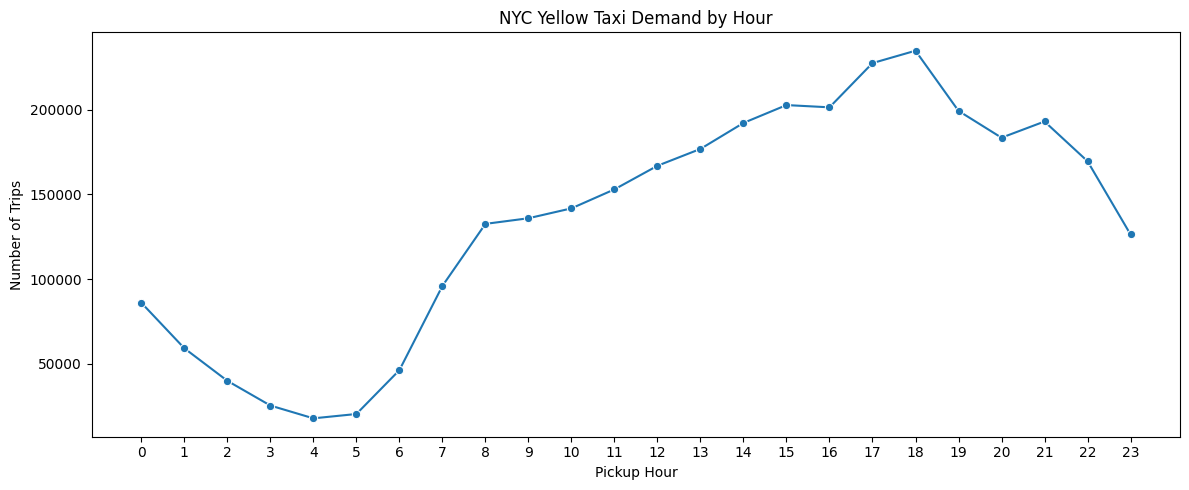

In [6]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_demand,
    x="pickup_hour",
    y="trip_count",
    marker="o"
)

plt.title("NYC Yellow Taxi Demand by Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [7]:
hourly_analysis = (
    df.groupby("pickup_hour")
      .agg(
          trip_count=("VendorID", "size"),
          total_revenue=("total_amount", "sum"),
          avg_fare=("total_amount", "mean"),
          avg_trip_distance=("trip_distance", "mean"),
          avg_duration=("trip_duration_min", "mean")
      )
      .reset_index()
)

hourly_analysis

,pickup_hour,trip_count,total_revenue,avg_fare,avg_trip_distance,avg_duration
0,0,86022,2346836.77,27.281821,3.671990,13.327739
1,1,59166,1488389.31,25.156159,3.231306,12.569075
2,2,39967,962177.98,24.074311,3.084100,12.064123
3,3,25394,634988.99,25.005473,3.429498,12.144670
4,4,17847,549030.71,30.763193,4.809818,14.017758
5,5,20406,708739.59,34.731921,5.785007,16.094597
6,6,46280,1346639.80,29.097662,4.559627,15.619711
7,7,95963,2562640.54,26.704465,3.585267,15.476615
8,8,132565,3346428.60,25.243681,2.981201,15.072492
9,9,135882,3448961.83,25.382036,2.900578,14.667528


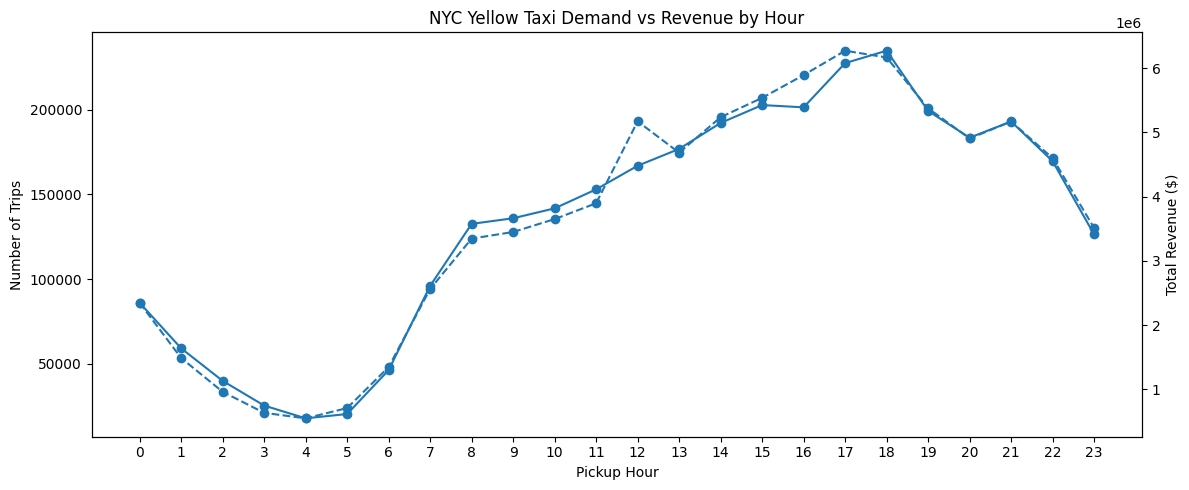

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    hourly_analysis["pickup_hour"],
    hourly_analysis["trip_count"],
    marker="o",
    label="Trips"
)

ax1.set_xlabel("Pickup Hour")
ax1.set_ylabel("Number of Trips")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()

ax2.plot(
    hourly_analysis["pickup_hour"],
    hourly_analysis["total_revenue"],
    marker="o",
    linestyle="--",
    label="Revenue"
)

ax2.set_ylabel("Total Revenue ($)")

plt.title("NYC Yellow Taxi Demand vs Revenue by Hour")
plt.tight_layout()
plt.show()

In [9]:
hourly_analysis["revenue_per_trip"] = (
    hourly_analysis["total_revenue"]
    / hourly_analysis["trip_count"]
)

hourly_analysis[
    ["pickup_hour", "trip_count", "total_revenue", "revenue_per_trip"]
]

,pickup_hour,trip_count,total_revenue,revenue_per_trip
0,0,86022,2346836.77,27.281821
1,1,59166,1488389.31,25.156159
2,2,39967,962177.98,24.074311
3,3,25394,634988.99,25.005473
4,4,17847,549030.71,30.763193
5,5,20406,708739.59,34.731921
6,6,46280,1346639.80,29.097662
7,7,95963,2562640.54,26.704465
8,8,132565,3346428.60,25.243681
9,9,135882,3448961.83,25.382036


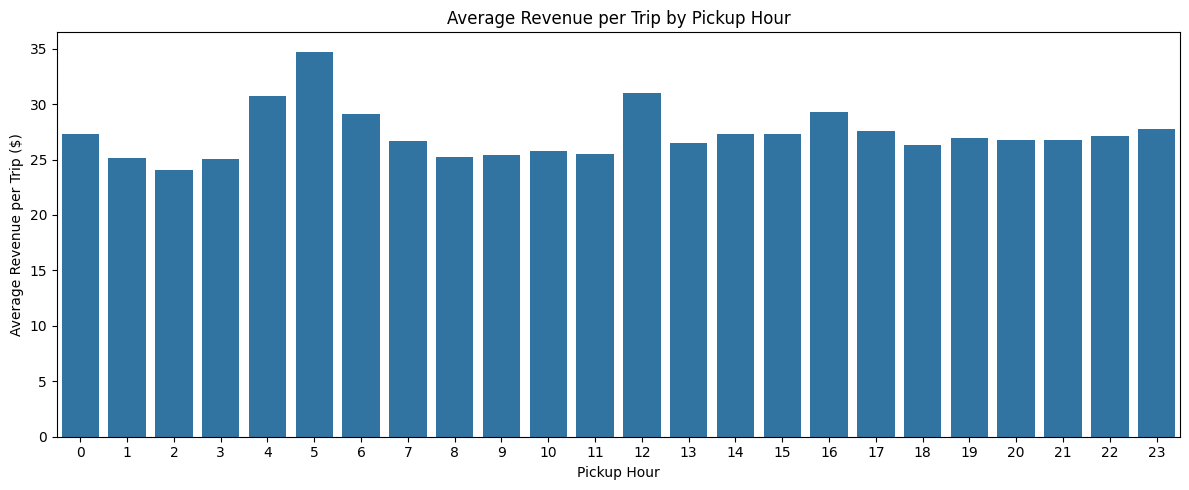

In [10]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=hourly_analysis,
    x="pickup_hour",
    y="revenue_per_trip"
)

plt.title("Average Revenue per Trip by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Revenue per Trip ($)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [11]:
day_analysis = (
    df.groupby(["pickup_day_of_week", "is_weekend"])
      .agg(
          trips=("VendorID", "size"),
          total_revenue=("total_amount", "sum"),
          avg_revenue_per_trip=("total_amount", "mean"),
          avg_distance=("trip_distance", "mean"),
          avg_duration=("trip_duration_min", "mean")
      )
      .reset_index()
)

day_analysis

,pickup_day_of_week,is_weekend,trips,total_revenue,avg_revenue_per_trip,avg_distance,avg_duration
0,Friday,False,540172,14618925.97,27.063465,3.136317,15.279404
1,Monday,False,340748,10459542.38,30.695829,3.530998,14.635736
2,Saturday,True,447935,11282404.20,25.187592,2.998238,13.942656
3,Sunday,True,375958,10089198.01,26.835971,3.482767,13.447328
4,Thursday,False,567135,15469026.17,27.275739,3.100052,15.420780
5,Tuesday,False,422664,11283328.55,26.695741,3.029138,14.725454
6,Wednesday,False,532758,14247034.33,26.742037,3.096760,14.809342


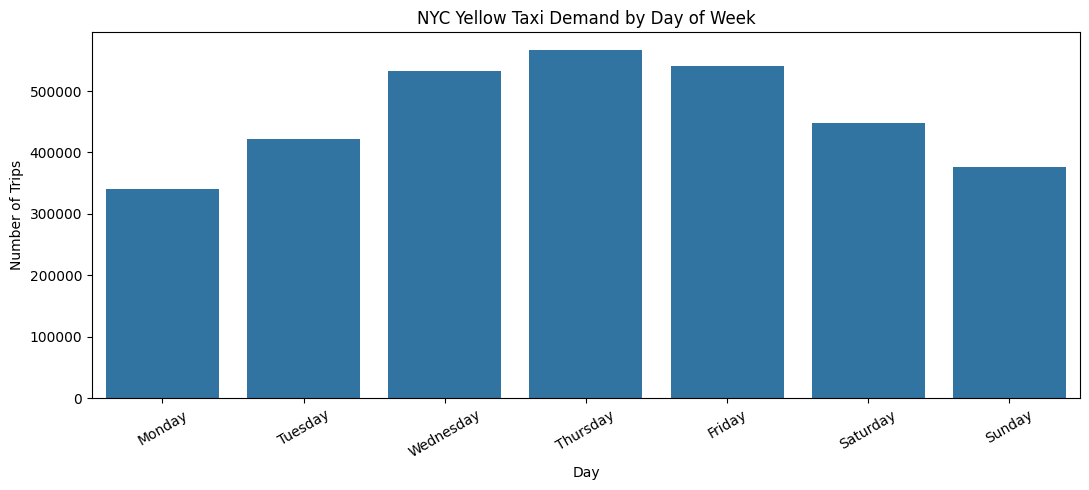

In [12]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(11, 5))

sns.barplot(
    data=day_analysis,
    x="pickup_day_of_week",
    y="trips",
    order=day_order
)

plt.title("NYC Yellow Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
weekday_analysis = (
    df.groupby(["pickup_date", "pickup_day_of_week"])
      .size()
      .reset_index(name="daily_trips")
)

weekday_avg = (
    weekday_analysis
    .groupby("pickup_day_of_week")
    .agg(
        avg_daily_trips=("daily_trips", "mean"),
        median_daily_trips=("daily_trips", "median")
    )
    .reset_index()
)

weekday_avg["pickup_day_of_week"] = pd.Categorical(
    weekday_avg["pickup_day_of_week"],
    categories=day_order,
    ordered=True
)

weekday_avg = weekday_avg.sort_values("pickup_day_of_week")

weekday_avg

,pickup_day_of_week,avg_daily_trips,median_daily_trips
1,Monday,85187.00,85450.5
5,Tuesday,105666.00,107420.0
6,Wednesday,106551.60,112116.0
4,Thursday,113427.00,122402.0
0,Friday,108034.40,110671.0
2,Saturday,111983.75,113383.0
3,Sunday,93989.50,95965.0


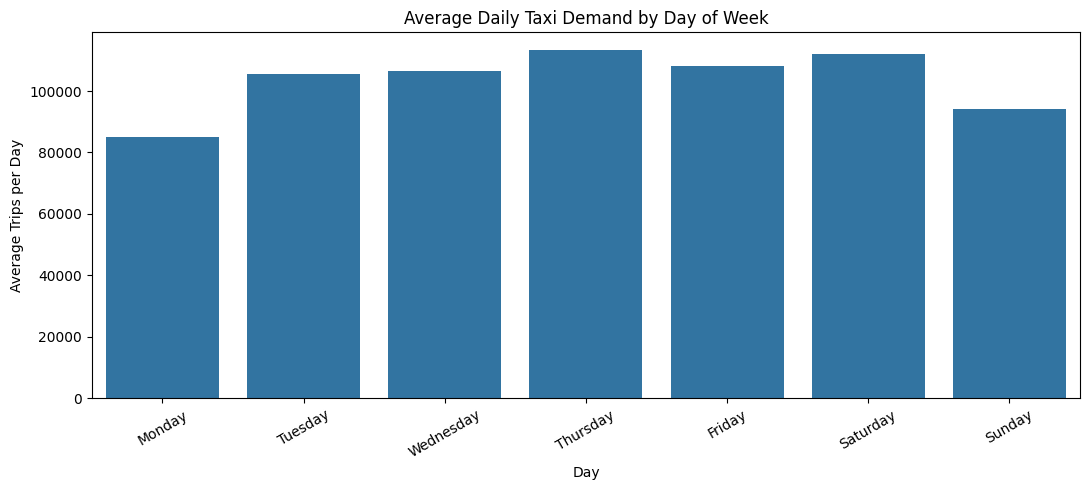

In [14]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=weekday_avg,
    x="pickup_day_of_week",
    y="avg_daily_trips",
    order=day_order
)

plt.title("Average Daily Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Trips per Day")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
heatmap_data = (
    df.groupby(["pickup_day_of_week", "pickup_hour"])
      .size()
      .reset_index(name="trip_count")
)

heatmap_pivot = heatmap_data.pivot(
    index="pickup_day_of_week",
    columns="pickup_hour",
    values="trip_count"
)

heatmap_pivot = heatmap_pivot.reindex(day_order)

heatmap_pivot

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,6756,3466,1981,1390,1656,2791,6419,12876,17284,16508,...,21798,23326,22467,24751,24887,20213,18521,18340,13237,8400
Tuesday,4290,1767,940,664,1002,2683,7428,17075,23923,22593,...,24832,26704,26648,31486,32655,25955,26776,29512,20190,10401
Wednesday,11213,9373,7140,4604,3412,3787,8522,18783,25666,24132,...,30141,32651,31908,38005,39386,33184,32522,35115,27486,13828
Thursday,6646,2843,1601,1171,1453,3444,9270,20026,27868,26801,...,32655,34830,34876,42209,44897,37067,36071,38587,33575,21368
Friday,10688,5342,2937,2010,2023,3844,8389,17769,22912,22192,...,32282,34377,32907,38781,40517,35001,29587,30365,32992,32063
Saturday,21308,16401,11374,6793,3518,1752,3063,4697,7705,12404,...,25569,27433,29250,28936,29457,28917,22544,24312,27336,29920
Sunday,25121,19974,13994,8762,4783,2105,3189,4737,7207,11252,...,24832,23324,23261,23243,22915,18883,17379,16727,14708,10341


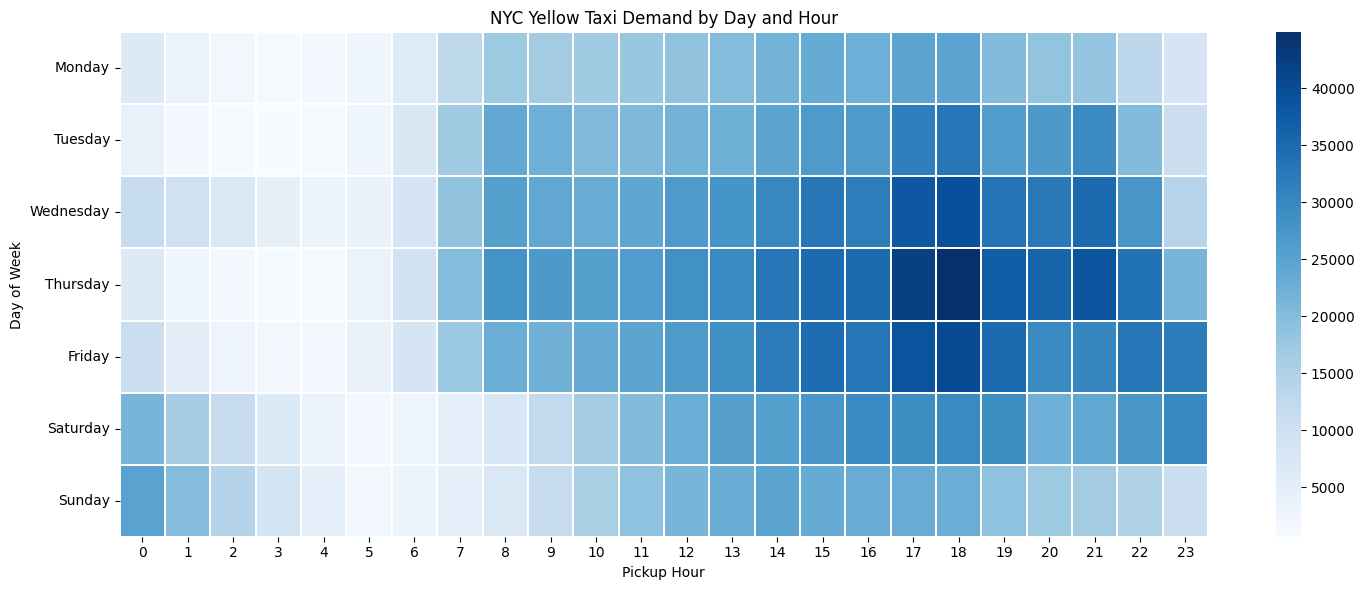

In [16]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    heatmap_pivot,
    cmap="Blues",
    linewidths=0.2
)

plt.title("NYC Yellow Taxi Demand by Day and Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

In [17]:
top_pickups = (
    df.groupby("PULocationID")
      .agg(
          trips=("VendorID", "size"),
          revenue=("total_amount", "sum"),
          avg_revenue=("total_amount", "mean")
      )
      .sort_values("trips", ascending=False)
      .head(15)
      .reset_index()
)

top_pickups

,PULocationID,trips,revenue,avg_revenue
0,161,159945,3833198.19,23.965727
1,237,156488,3110152.55,19.874703
2,236,148377,3012713.30,20.304449
3,132,134237,10860418.66,80.904808
4,230,117306,3146705.72,26.824764
5,186,112983,2710303.77,23.988598
6,162,111665,2636293.89,23.608954
7,142,104944,2271205.59,21.642072
8,239,91082,1928380.44,21.171916
9,163,90785,2196509.17,24.194627


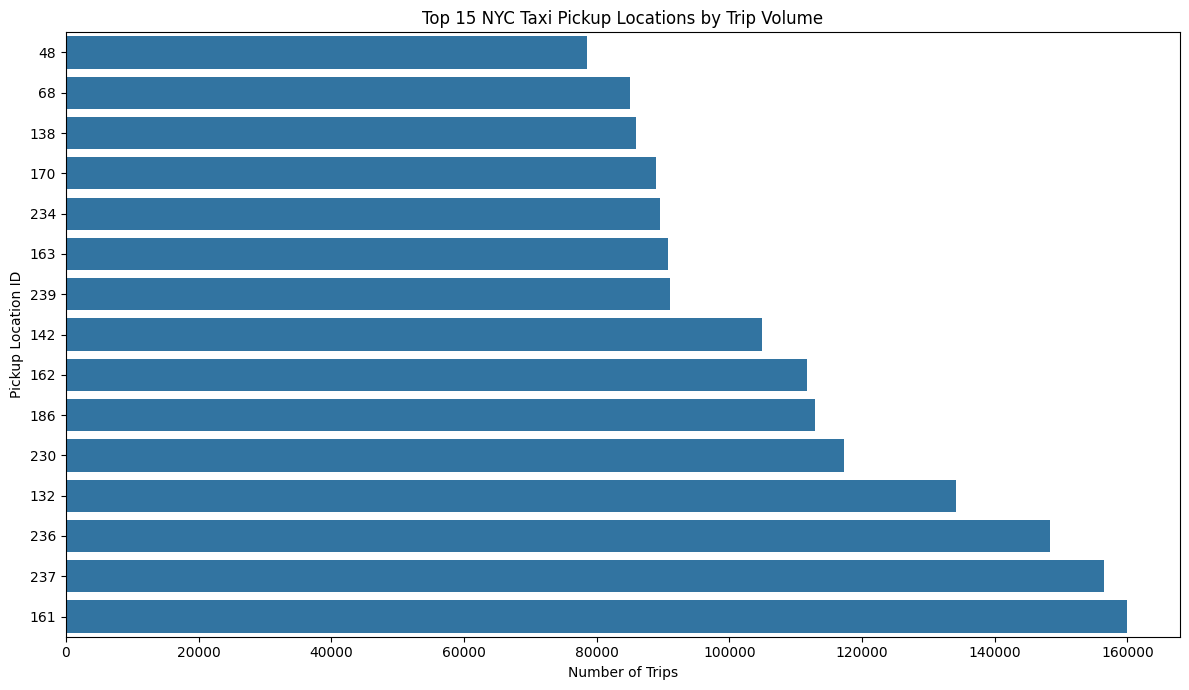

In [20]:
plot_data = top_pickups.copy()

# Treat location IDs as categories
plot_data["PULocationID"] = (
    plot_data["PULocationID"]
    .astype(str)
)

plot_data = plot_data.sort_values(
    "trips",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_data,
    x="trips",
    y="PULocationID"
)

plt.title("Top 15 NYC Taxi Pickup Locations by Trip Volume")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Location ID")

plt.tight_layout()
plt.show()

In [21]:
top_pickups.sort_values(
    "trips",
    ascending=False
)

,PULocationID,trips,revenue,avg_revenue
0,161,159945,3833198.19,23.965727
1,237,156488,3110152.55,19.874703
2,236,148377,3012713.30,20.304449
3,132,134237,10860418.66,80.904808
4,230,117306,3146705.72,26.824764
5,186,112983,2710303.77,23.988598
6,162,111665,2636293.89,23.608954
7,142,104944,2271205.59,21.642072
8,239,91082,1928380.44,21.171916
9,163,90785,2196509.17,24.194627


In [22]:
# Load NYC Taxi Zone Lookup
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")

zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [23]:
# Add zone names to top pickup analysis

top_pickups_named = top_pickups.merge(
    zones[["LocationID", "Zone", "Borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

top_pickups_named = (
    top_pickups_named
    .sort_values("trips", ascending=False)
    [["PULocationID", "Zone", "Borough", "trips", "revenue", "avg_revenue"]]
)

top_pickups_named

,PULocationID,Zone,Borough,trips,revenue,avg_revenue
0,161,Midtown Center,Manhattan,159945,3833198.19,23.965727
1,237,Upper East Side South,Manhattan,156488,3110152.55,19.874703
2,236,Upper East Side North,Manhattan,148377,3012713.30,20.304449
3,132,JFK Airport,Queens,134237,10860418.66,80.904808
4,230,Times Sq/Theatre District,Manhattan,117306,3146705.72,26.824764
5,186,Penn Station/Madison Sq West,Manhattan,112983,2710303.77,23.988598
6,162,Midtown East,Manhattan,111665,2636293.89,23.608954
7,142,Lincoln Square East,Manhattan,104944,2271205.59,21.642072
8,239,Upper West Side South,Manhattan,91082,1928380.44,21.171916
9,163,Midtown North,Manhattan,90785,2196509.17,24.194627


In [24]:
print(top_pickups_named.to_string(index=False))

 PULocationID                         Zone   Borough  trips     revenue  avg_revenue
          161               Midtown Center Manhattan 159945  3833198.19    23.965727
          237        Upper East Side South Manhattan 156488  3110152.55    19.874703
          236        Upper East Side North Manhattan 148377  3012713.30    20.304449
          132                  JFK Airport    Queens 134237 10860418.66    80.904808
          230    Times Sq/Theatre District Manhattan 117306  3146705.72    26.824764
          186 Penn Station/Madison Sq West Manhattan 112983  2710303.77    23.988598
          162                 Midtown East Manhattan 111665  2636293.89    23.608954
          142          Lincoln Square East Manhattan 104944  2271205.59    21.642072
          239        Upper West Side South Manhattan  91082  1928380.44    21.171916
          163                Midtown North Manhattan  90785  2196509.17    24.194627
          234                     Union Sq Manhattan  89629  1954

In [25]:
zone_performance = top_pickups_named.copy()

zone_performance["revenue_per_trip"] = (
    zone_performance["revenue"] / zone_performance["trips"]
)

zone_performance = zone_performance.sort_values(
    "revenue",
    ascending=False
)

print(
    zone_performance[
        [
            "Zone",
            "Borough",
            "trips",
            "revenue",
            "revenue_per_trip"
        ]
    ].to_string(index=False)
)

                        Zone   Borough  trips     revenue  revenue_per_trip
                 JFK Airport    Queens 134237 10860418.66         80.904808
           LaGuardia Airport    Queens  85929  6605779.98         76.874862
              Midtown Center Manhattan 159945  3833198.19         23.965727
   Times Sq/Theatre District Manhattan 117306  3146705.72         26.824764
       Upper East Side South Manhattan 156488  3110152.55         19.874703
       Upper East Side North Manhattan 148377  3012713.30         20.304449
Penn Station/Madison Sq West Manhattan 112983  2710303.77         23.988598
                Midtown East Manhattan 111665  2636293.89         23.608954
         Lincoln Square East Manhattan 104944  2271205.59         21.642072
               Midtown North Manhattan  90785  2196509.17         24.194627
                East Chelsea Manhattan  84965  2089228.12         24.589279
                 Murray Hill Manhattan  88907  2051088.76         23.070048
            

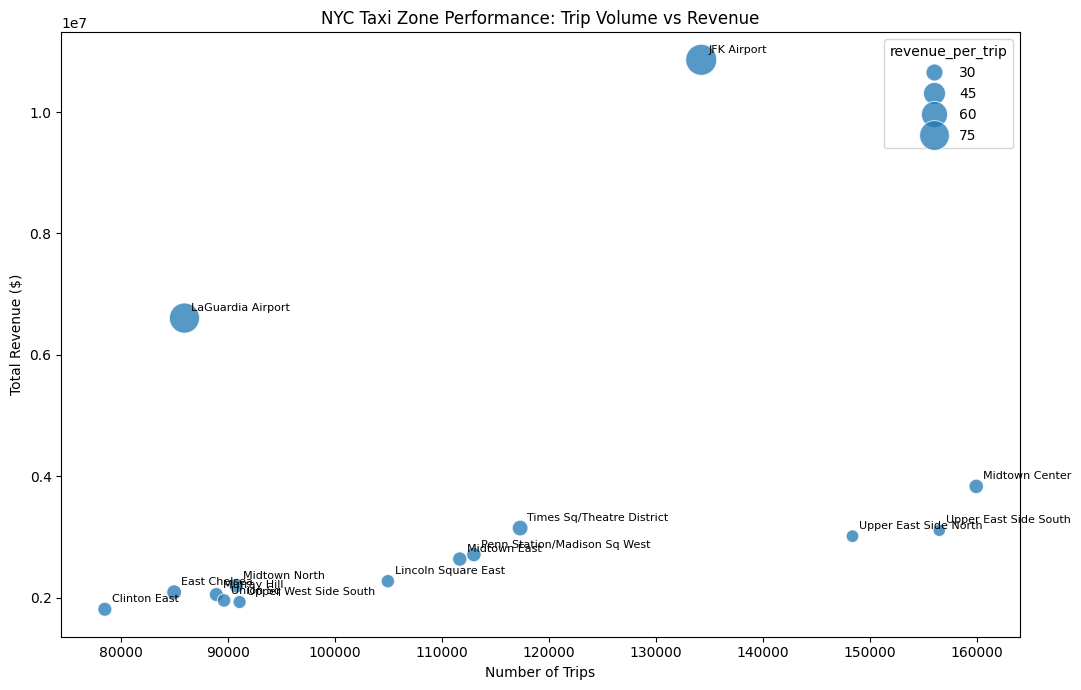

In [26]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=zone_performance,
    x="trips",
    y="revenue",
    size="revenue_per_trip",
    sizes=(80, 500),
    alpha=0.75
)

for _, row in zone_performance.iterrows():
    plt.annotate(
        row["Zone"],
        (row["trips"], row["revenue"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("NYC Taxi Zone Performance: Trip Volume vs Revenue")
plt.xlabel("Number of Trips")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()

In [27]:
trip_economics = df[
    [
        "trip_distance",
        "trip_duration_min",
        "fare_amount",
        "tip_amount",
        "total_amount",
        "tip_rate"
    ]
].describe()

trip_economics

,trip_distance,trip_duration_min,fare_amount,tip_amount,total_amount,tip_rate
count,3.227370e+06,3.227370e+06,3.227370e+06,3.227370e+06,3.227370e+06,3.227370e+06
mean,3.172242e+00,1.468720e+01,1.823208e+01,3.121996e+00,2.709620e+01,1.993363e-01
std,4.150510e+00,1.135449e+01,4.808542e+02,3.756882e+00,4.810137e+02,2.233648e+00
min,1.000000e-02,1.666667e-02,1.000000e-02,0.000000e+00,1.010000e+00,0.000000e+00
25%,1.010000e+00,7.333333e+00,8.600000e+00,0.000000e+00,1.595000e+01,0.000000e+00
50%,1.700000e+00,1.170000e+01,1.280000e+01,2.590000e+00,2.037000e+01,2.392226e-01
75%,3.150000e+00,1.833333e+01,1.980000e+01,4.000000e+00,2.825000e+01,3.021127e-01
max,9.758000e+01,1.799667e+02,8.633721e+05,4.000000e+02,8.633804e+05,4.000000e+03


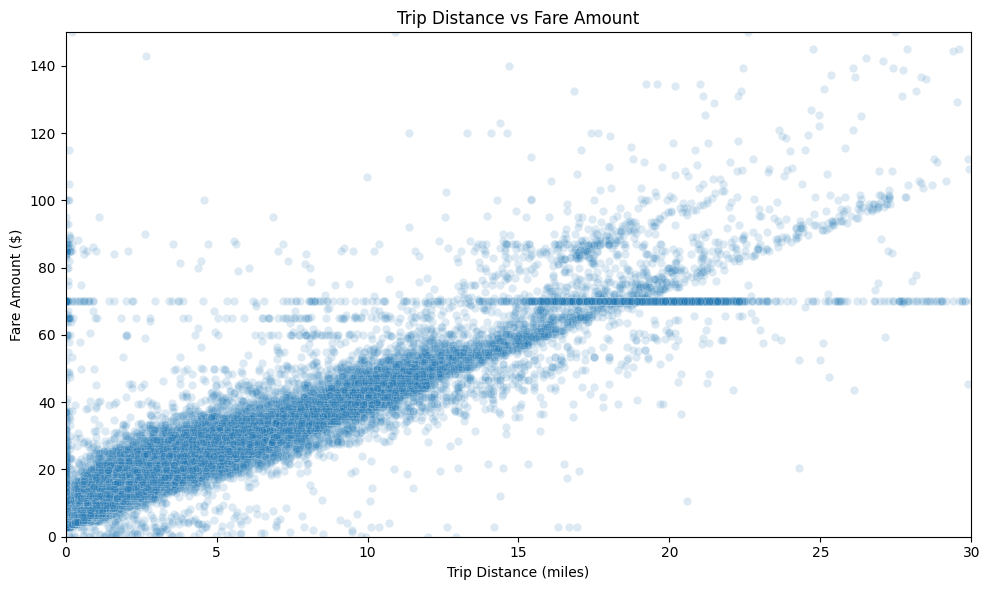

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(100000, random_state=42),
    x="trip_distance",
    y="fare_amount",
    alpha=0.15
)

plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.xlim(0, 30)
plt.ylim(0, 150)
plt.tight_layout()
plt.show()

In [29]:
payment_analysis = (
    df.groupby("payment_type_label")
      .agg(
          trips=("payment_type_label", "size"),
          avg_fare=("fare_amount", "mean"),
          avg_tip=("tip_amount", "mean"),
          avg_tip_rate=("tip_rate", "mean"),
          total_revenue=("total_amount", "sum")
      )
      .sort_values("trips", ascending=False)
)

print(payment_analysis.to_string())

                      trips   avg_fare   avg_tip  avg_tip_rate  total_revenue
payment_type_label                                                           
Credit card         2403301  17.867745  4.098272      0.262971    67165489.14
Flex Fare            413133  18.146892  0.546969      0.027385     9566360.10
Cash                 363735  18.025818  0.000271      0.000019     8589512.92
Dispute               35456  45.915098  0.009841      0.000329     1842601.89
No charge             11745  18.597579  0.003146      0.000153      285495.56


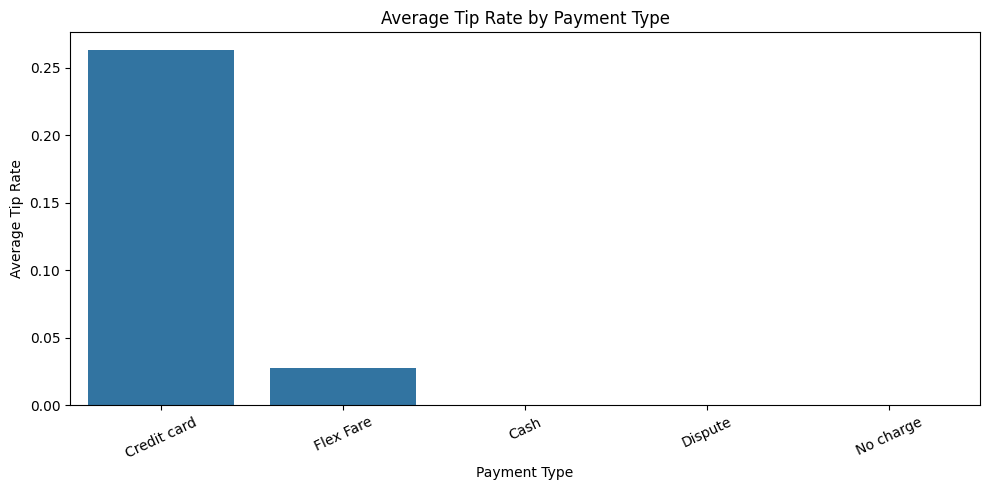

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_analysis.reset_index(),
    x="payment_type_label",
    y="avg_tip_rate"
)

plt.title("Average Tip Rate by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip Rate")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [31]:
payment_mix = (
    df.groupby("payment_type_label")
      .size()
      .sort_values(ascending=False)
)

print(payment_mix.to_string())

payment_type_label
Credit card    2403301
Flex Fare       413133
Cash            363735
Dispute          35456
No charge        11745


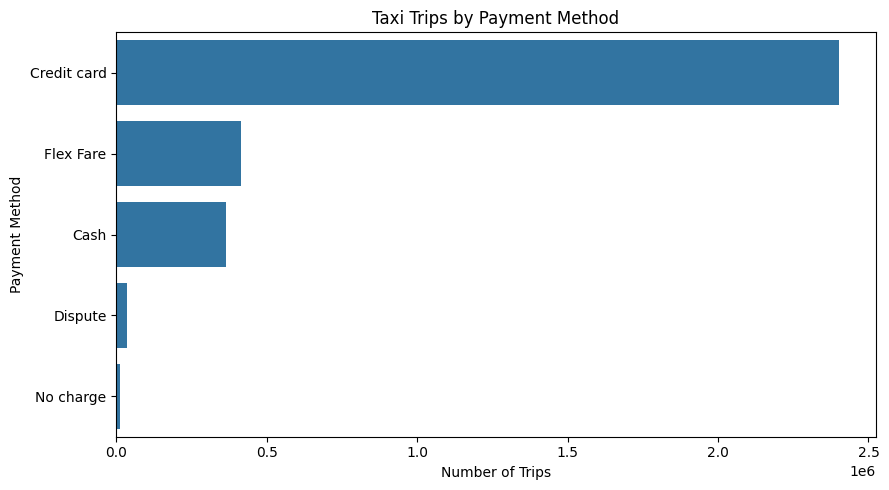

In [32]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_mix.values,
    y=payment_mix.index
)

plt.title("Taxi Trips by Payment Method")
plt.xlabel("Number of Trips")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

In [33]:
payment_summary = (
    df.groupby("payment_type_label")
      .agg(
          trips=("payment_type_label", "size"),
          avg_tip_rate=("tip_rate", "mean"),
          avg_tip=("tip_amount", "mean"),
          total_revenue=("total_amount", "sum")
      )
)

payment_summary["trip_share_pct"] = (
    payment_summary["trips"] / len(df) * 100
)

payment_summary = payment_summary.sort_values(
    "trips", ascending=False
)

print(payment_summary.round(2).to_string())

                      trips  avg_tip_rate  avg_tip  total_revenue  trip_share_pct
payment_type_label                                                               
Credit card         2403301          0.26     4.10    67165489.14           74.47
Flex Fare            413133          0.03     0.55     9566360.10           12.80
Cash                 363735          0.00     0.00     8589512.92           11.27
Dispute               35456          0.00     0.01     1842601.89            1.10
No charge             11745          0.00     0.00      285495.56            0.36


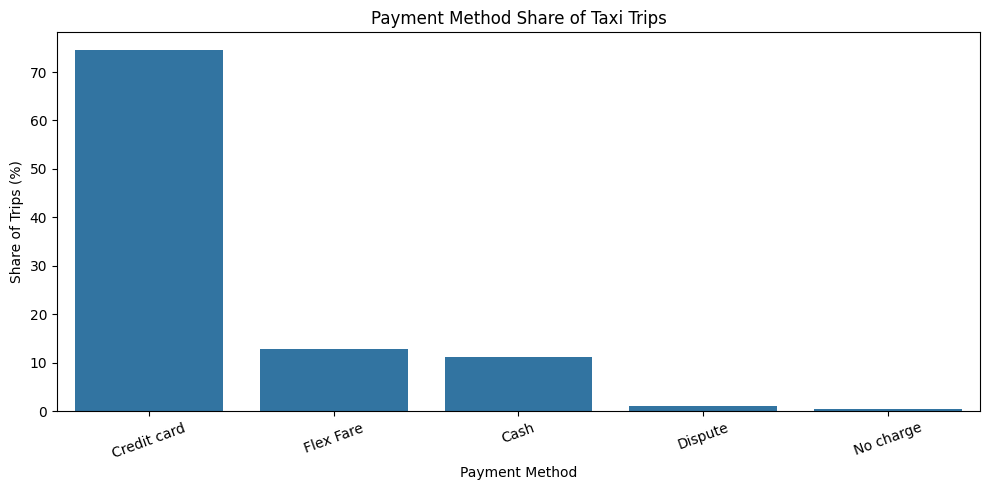

In [34]:
plt.figure(figsize=(10, 5))

plot_payment = payment_summary.reset_index()

sns.barplot(
    data=plot_payment,
    x="payment_type_label",
    y="trip_share_pct"
)

plt.title("Payment Method Share of Taxi Trips")
plt.xlabel("Payment Method")
plt.ylabel("Share of Trips (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [36]:
df["duration_per_mile"] = df["trip_duration_min"] / df["trip_distance"]

df[["trip_duration_min", "trip_distance", "duration_per_mile"]].head()

,trip_duration_min,trip_distance,duration_per_mile
0,8.350000,1.60,5.218750
1,2.550000,0.50,5.100000
2,1.950000,0.60,3.250000
3,5.566667,0.52,10.705128
4,3.533333,0.66,5.353535


In [37]:
# Average trip inefficiency by pickup hour

hour_inefficiency = (
    df.groupby("pickup_hour")["duration_per_mile"]
      .mean()
      .sort_values(ascending=False)
)

hour_inefficiency

pickup_hour
18    25.242980
17    21.816104
19    18.273869
16    14.312714
11     7.738150
15     7.737063
12     7.690170
13     7.655401
14     7.547763
10     7.453977
9      7.379126
8      6.979539
20     6.056109
7      6.009434
21     5.942019
22     5.849714
2      5.565669
1      5.393094
23     5.353903
0      5.302600
3      4.968896
6      4.812142
4      4.617979
5      4.110246
Name: duration_per_mile, dtype: float64

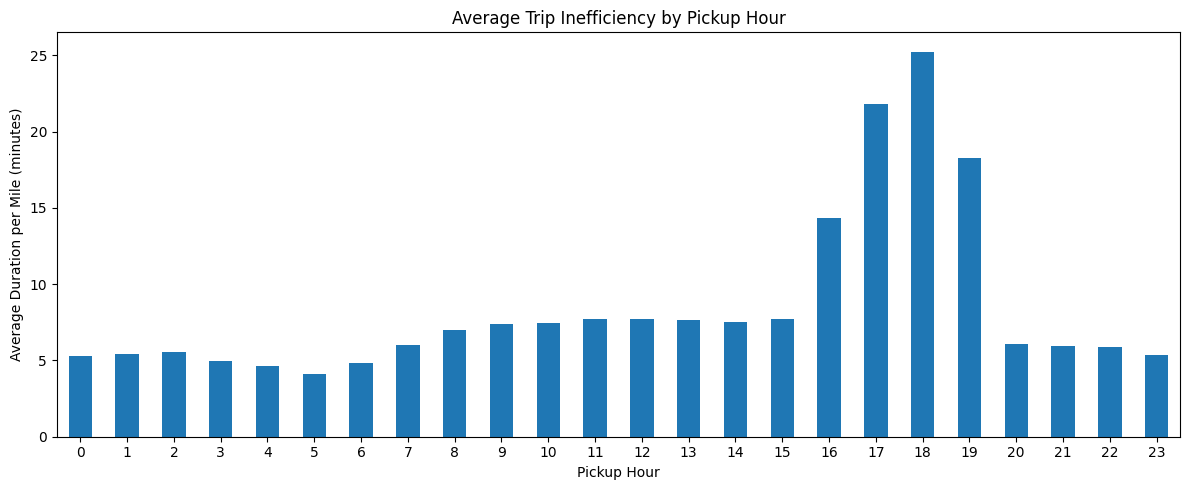

In [38]:
plt.figure(figsize=(12, 5))

hour_inefficiency.sort_index().plot(kind="bar")

plt.title("Average Trip Inefficiency by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Duration per Mile (minutes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
zone_inefficiency = (
    df.groupby("PULocationID")
      .agg(
          trips=("PULocationID", "size"),
          avg_duration_per_mile=("duration_per_mile", "mean")
      )
      .query("trips >= 1000")
      .sort_values("avg_duration_per_mile", ascending=False)
      .head(15)
)

zone_inefficiency

,trips,avg_duration_per_mile
PULocationID,,
95,1107,35.359412
66,1710,34.874597
65,2210,34.474235
25,1897,31.942675
33,2107,30.699682
244,2652,30.513557
97,2100,30.136621
168,1122,28.421563
181,1846,25.759174


In [41]:
taxi_zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")

In [42]:
zone_inefficiency = (
    df[df["trip_distance"] >= 1]
    .groupby("PULocationID")
    .agg(
        trips=("PULocationID", "size"),
        avg_duration_per_mile=("duration_per_mile", "mean")
    )
    .query("trips >= 1000")
    .sort_values("avg_duration_per_mile", ascending=False)
    .head(15)
    .reset_index()
)

zone_inefficiency = zone_inefficiency.merge(
    taxi_zones[["LocationID", "Zone", "Borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_inefficiency[[
    "PULocationID", "Zone", "Borough",
    "trips", "avg_duration_per_mile"
]]

,PULocationID,Zone,Borough,trips,avg_duration_per_mile
0,186,Penn Station/Madison Sq West,Manhattan,87271,7.509653
1,188,Prospect-Lefferts Gardens,Brooklyn,1674,7.299501
2,225,Stuyvesant Heights,Brooklyn,1247,7.236934
3,61,Crown Heights North,Brooklyn,2439,7.177623
4,161,Midtown Center,Manhattan,117519,7.138915
5,17,Bedford,Brooklyn,1185,7.054834
6,72,East Flatbush/Remsen Village,Brooklyn,1198,7.047114
7,163,Midtown North,Manhattan,67117,7.025588
8,35,Brownsville,Brooklyn,1240,7.021509
9,162,Midtown East,Manhattan,82570,6.962345


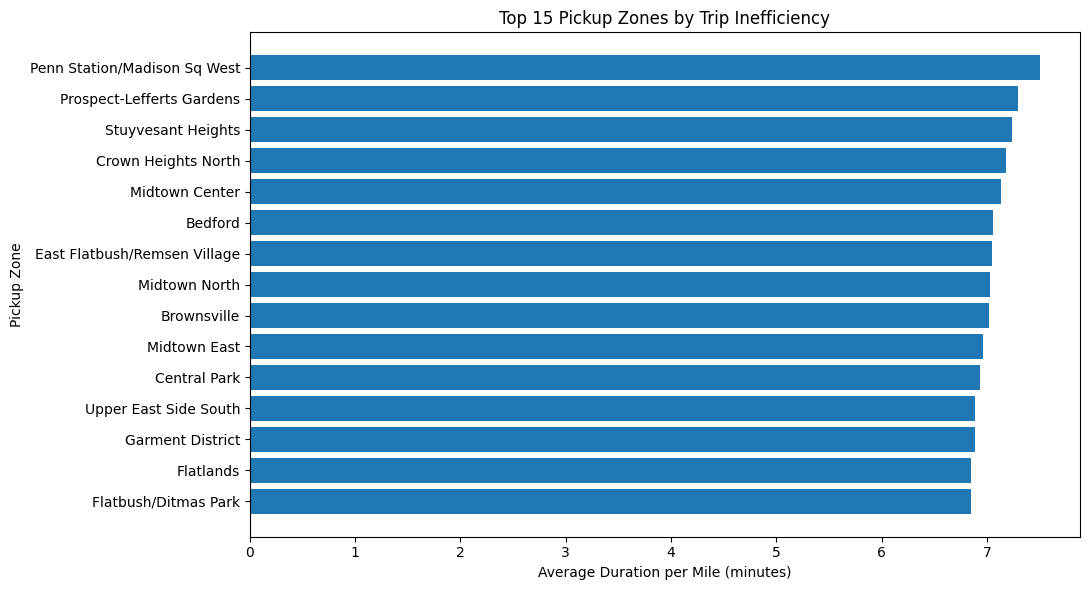

In [43]:
plt.figure(figsize=(11, 6))

plot_data = zone_inefficiency.sort_values("avg_duration_per_mile")

plt.barh(
    plot_data["Zone"],
    plot_data["avg_duration_per_mile"]
)

plt.title("Top 15 Pickup Zones by Trip Inefficiency")
plt.xlabel("Average Duration per Mile (minutes)")
plt.ylabel("Pickup Zone")
plt.tight_layout()
plt.show()

In [44]:
# Q5: Trip performance by vendor

vendor_performance = (
    df.groupby("VendorID")
      .agg(
          trips=("VendorID", "size"),
          avg_fare_per_mile=("fare_per_mile", "mean"),
          avg_duration_per_mile=("duration_per_mile", "mean"),
          avg_tip_rate=("tip_rate", "mean")
      )
      .round(3)
)

vendor_performance

,trips,avg_fare_per_mile,avg_duration_per_mile,avg_tip_rate
VendorID,,,,
1,714026,8.755,7.275,0.200
2,2513007,17.459,11.161,0.199
6,337,0.680,6.016,0.000


In [45]:
rate_performance = (
    df.groupby("ratecode_label")
      .agg(
          trips=("ratecode_label", "size"),
          avg_fare_per_mile=("fare_per_mile", "mean"),
          avg_duration_per_mile=("duration_per_mile", "mean"),
          avg_tip_rate=("tip_rate", "mean")
      )
      .sort_values("trips", ascending=False)
      .round(3)
)

rate_performance

,trips,avg_fare_per_mile,avg_duration_per_mile,avg_tip_rate
ratecode_label,,,,
Standard rate,2658642,8.430,7.029,0.229
Unknown/Null,452120,37.781,31.391,0.025
JFK,88008,51.193,2.928,0.169
Negotiated fare,14629,393.874,4.904,0.414
Newark,7394,44.702,2.722,0.152
Nassau or Westchester,6570,5.460,2.161,0.125
Group ride,7,14.405,2.707,0.000


In [46]:
zone_performance = (
    df.groupby("PULocationID")
      .agg(
          trips=("PULocationID", "size"),
          avg_fare_per_mile=("fare_per_mile", "mean"),
          avg_duration_per_mile=("duration_per_mile", "mean"),
          avg_tip_rate=("tip_rate", "mean")
      )
      .query("trips >= 5000")
      .sort_values("trips", ascending=False)
      .head(15)
      .reset_index()
)

zone_performance = zone_performance.merge(
    taxi_zones[["LocationID", "Zone", "Borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_performance[[
    "Zone", "Borough", "trips",
    "avg_fare_per_mile",
    "avg_duration_per_mile",
    "avg_tip_rate"
]]

,Zone,Borough,trips,avg_fare_per_mile,avg_duration_per_mile,avg_tip_rate
0,Midtown Center,Manhattan,159945,14.379880,11.270581,0.216656
1,Upper East Side South,Manhattan,156488,11.769985,9.159151,0.230943
2,Upper East Side North,Manhattan,148377,11.996202,9.234218,0.223495
3,JFK Airport,Queens,134237,17.866288,2.737286,0.143000
4,Times Sq/Theatre District,Manhattan,117306,14.174596,9.446887,0.208087
5,Penn Station/Madison Sq West,Manhattan,112983,11.676049,9.458670,0.214582
6,Midtown East,Manhattan,111665,13.121397,10.322827,0.225067
7,Lincoln Square East,Manhattan,104944,10.601879,7.660563,0.224937
8,Upper West Side South,Manhattan,91082,11.824366,8.411275,0.222355
9,Midtown North,Manhattan,90785,14.092711,9.514595,0.219950


In [49]:
[c for c in df.columns if "vendor" in c.lower()]

['VendorID']

In [51]:
vendor_performance = (
    df.groupby("VendorID")
      .agg(
          trips=("VendorID", "size"),
          avg_fare_per_mile=("fare_per_mile", "mean"),
          avg_duration_per_mile=("duration_per_mile", "mean"),
          avg_tip_rate=("tip_rate", "mean")
      )
      .sort_values("trips", ascending=False)
      .round(3)
)

vendor_performance

,trips,avg_fare_per_mile,avg_duration_per_mile,avg_tip_rate
VendorID,,,,
2,2513007,17.459,11.161,0.199
1,714026,8.755,7.275,0.200
6,337,0.680,6.016,0.000


In [52]:
[c for c in df.columns if "hour" in c.lower()]

['pickup_hour']

In [53]:
hour_performance = (
    df.groupby("pickup_hour")
      .agg(
          trips=("pickup_hour", "size"),
          avg_fare_per_mile=("fare_per_mile", "mean"),
          avg_duration_per_mile=("duration_per_mile", "mean"),
          avg_tip_rate=("tip_rate", "mean")
      )
      .sort_values("trips", ascending=False)
      .round(3)
)

hour_performance

,trips,avg_fare_per_mile,avg_duration_per_mile,avg_tip_rate
pickup_hour,,,,
18,234714,32.536,25.243,0.218
17,227411,27.282,21.816,0.221
15,202645,12.751,7.737,0.218
16,201317,20.095,14.313,0.221
19,199220,24.407,18.274,0.217
21,192958,10.118,5.942,0.200
14,192109,12.601,7.548,0.198
20,183400,9.750,6.056,0.205
13,176782,12.422,7.655,0.200


In [54]:
profitable_patterns = (
    df.groupby(["pickup_hour", "ratecode_label"])
      .agg(
          trips=("pickup_hour", "size"),
          avg_fare_per_mile=("fare_per_mile", "mean"),
          avg_tip_rate=("tip_rate", "mean"),
          avg_revenue=("total_amount", "mean")
      )
      .query("trips >= 1000")
      .sort_values("avg_revenue", ascending=False)
      .round(3)
)

profitable_patterns.head(15)

trips  avg_fare_per_mile  avg_tip_rate  \
pickup_hour ratecode_label                                            
16          Negotiated fare   1120            375.892         0.140   
            JFK               8417             41.362         0.179   
19          JFK               5605             53.179         0.179   
17          JFK               6304             43.426         0.171   
18          JFK               5049             63.138         0.167   
15          Negotiated fare   1165            441.549         3.574   
            JFK               7210             43.597         0.172   
22          JFK               4453             45.785         0.173   
21          JFK               5114             50.408         0.172   
8           JFK               2563             46.604         0.167   
20          JFK               5312             50.627         0.170   
14          JFK               6461             44.465         0.165   
7           JFK               3064             30.578         0.162   
13          JFK               5043             51.710         0.164   
6           JFK               2288             28.696         0.165   

                             avg_revenue  
pickup_hour ratecode_label                
16          Negotiated fare       97.514  
            JFK                   97.211  
19          JFK                   96.956  
17          JFK                   96.763  
18          JFK                   96.253  
15          Negotiated fare       95.686  
            JFK                   93.462  
22          JFK                   93.124  
21          JFK                   93.038  
8           JFK                   93.037  
20          JFK                   93.021  
14          JFK                   92.978  
7           JFK                   92.917  
13          JFK                   92.829  
6           JFK                   92.822

In [55]:
capacity_priority = (
    df.groupby(["pickup_hour", "PULocationID"])
      .agg(
          trips=("PULocationID", "size"),
          avg_revenue=("total_amount", "mean"),
          avg_duration_per_mile=("duration_per_mile", "mean")
      )
      .reset_index()
)

capacity_priority = capacity_priority.merge(
    taxi_zones[["LocationID", "Zone", "Borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

capacity_priority = (
    capacity_priority[
        capacity_priority["trips"] >= 1000
    ]
    .sort_values("trips", ascending=False)
    .head(20)
    .round(3)
)

capacity_priority[
    ["pickup_hour", "Zone", "Borough", "trips",
     "avg_revenue", "avg_duration_per_mile"]
]

,pickup_hour,Zone,Borough,trips,avg_revenue,avg_duration_per_mile
4314,18,Midtown Center,Manhattan,15859,23.873,19.765
4081,17,Midtown Center,Manhattan,15305,25.024,17.551
3681,15,Upper East Side North,Manhattan,13058,19.858,8.482
4543,19,Midtown Center,Manhattan,12848,23.382,18.395
3443,14,Upper East Side South,Manhattan,12745,19.218,8.652
5073,21,Times Sq/Theatre District,Manhattan,12590,23.027,7.405
4777,20,Midtown Center,Manhattan,12528,22.378,6.726
3682,15,Upper East Side South,Manhattan,12301,19.376,8.451
3850,16,Midtown Center,Manhattan,12233,25.126,12.441
4148,17,Upper East Side South,Manhattan,11918,21.324,13.916
